# SentimentScope: Sentiment Analysis using Transformers!
## <a name="introduction"></a> Introduction 

This project explores transformer-based sentiment analysis using the IMDB movie review dataset. The model is trained to classify reviews as either positive or negative based on their text content.

The project was completed as part of the Udacity AWS AI Scientist learning journey, where I worked through data preparation, transformer implementation, training, and evaluation while building a deeper understanding of NLP workflows.

The main objective of this project is to understand how transformer architectures can be adapted for text classification tasks using PyTorch.

By completing this project, the following skills were applied and strengthened:

* Loading and preparing text data for transformer models using PyTorch
* Using pretrained tokenizers for text preprocessing
* Customizing transformer architectures for classification tasks
* Training and evaluating a transformer model on real-world text data

## Project Structure

The notebook is organized into the following sections:

1. Introduction
2. Load, Explore, and Prepare the Dataset
3. Implement a DataLoader in PyTorch
4. Customize the Transformer Architecture
5. Implement Accuracy Calculation
6. Train the Model
7. Test the Model
8. Conclusion

## Sentiment Analysis Overview

Sentiment analysis is a natural language processing (NLP) task used to determine the sentiment expressed in text data.

In this project, sentiment analysis is treated as a binary classification problem:

* Positive reviews → label 1
* Negative reviews → label 0

For example:

* A positive review expresses enjoyment or satisfaction
* A negative review expresses criticism or dissatisfaction

## Dataset Description

The IMDB dataset is used for this project. It contains movie reviews divided into training and testing folders.

### Directory Structure

```text
aclIMDB/
├── train/
│   ├── pos
│   ├── neg
│   ├── unsup
├── test/
│   ├── pos
│   ├── neg
```

* `pos` → positive reviews
* `neg` → negative reviews
* `unsup` → unlabeled reviews not used in this project

## 🔹 Preparing the IMDB Dataset

The IMDB dataset is provided as a compressed archive. After extraction, the review files can be loaded and prepared for preprocessing and model training.

In [1]:
import os 
import pandas as pd

# Unpack the dataset - uncomment the line below to run
# !tar -xzf aclImdb_v1.tar.gz

In [ ]:
# Dataset folders for positive and negative movie reviews

train_pos_path = 'aclImdb/train/pos'  # positive training reviews
train_neg_path = 'aclImdb/train/neg'  # negative training reviews
test_pos_path = 'aclImdb/test/pos'    # positive test reviews
test_neg_path = 'aclImdb/test/neg'    # negative test reviews

## 🔹 Loading Review Files

The helper function below loads review text files from a selected dataset folder and stores them as a Python list for further preprocessing.

In [ ]:
import os

def load_dataset(aclImdb):
    """
    Reads all text files in the specified folder and returns their content as a list.

    Args:
        aclImdb (str): Path to the folder containing text files.

    Returns:
        list: A list of strings, where each string is the content of a text file.
    """

    texts = []

    # Validate dataset folder before loading files
    if not os.path.isdir(aclImdb):
        raise FileNotFoundError(f"Folder not found: {aclImdb}")

    # Read each review file from the dataset folder
    for fname in sorted(os.listdir(aclImdb)):

        # Skip hidden/system files (e.g. .DS_Store)
        if fname.startswith('.'):
            continue

        # Ensure only text files are processed
        if not fname.lower().endswith('.txt'):
            continue

        # Construct full file path
        full_path = os.path.join(aclImdb, fname)

        # Read file content safely
        try:
            with open(full_path, "r", encoding="utf-8") as f:
                texts.append(f.read())
        except UnicodeDecodeError:
            # Fallback encoding for non-UTF-8 files
            with open(full_path, "r", encoding="latin-1") as f:
                texts.append(f.read())

    return texts

## 🔹 Loading Training and Test Reviews

The dataset is separated into positive and negative reviews for both training and testing. Each group is loaded individually before combining them into structured datasets.

In [ ]:
# Load positive and negative reviews for training and testing

train_pos = load_dataset(train_pos_path)
train_neg = load_dataset(train_neg_path)
test_pos = load_dataset(test_pos_path)
test_neg = load_dataset(test_neg_path)

# Quick validation of dataset sizes
print("Number of training positive reviews:", len(train_pos))
print("Number of training negative reviews:", len(train_neg))
print("Number of testing positive reviews:", len(test_pos))
print("Number of testing negative reviews:", len(test_neg))

Number of training positive reviews: 12500
Number of training negative reviews: 12500
Number of testing positive reviews: 12500
Number of testing negative reviews: 12500


## 🔹 Building Structured DataFrames

The loaded reviews are combined into Pandas DataFrames to simplify labeling, preprocessing, and model preparation.

Positive and negative reviews are combined and assigned binary labels:

Positive → 1
Negative → 0

In [ ]:
# Combine reviews and sentiment labels into the training dataset
# Labels: 1 = positive sentiment, 0 = negative sentiment

train_df = pd.DataFrame({
    'review': train_pos + train_neg,
    'label': [1] * len(train_pos) + [0] * len(train_neg)
})

# Build the testing dataset using the same structure
test_df = pd.DataFrame({
    'review': test_pos + test_neg,
    'label': [1] * len(test_pos) + [0] * len(test_neg)
})

# Preview dataset structure and labels
print(train_df.head())

# Verify column structure for both datasets
print("Training DataFrame columns:", train_df.columns.tolist())
print("Testing DataFrame columns:", test_df.columns.tolist())

                                              review  label
0  Bromwell High is a cartoon comedy. It ran at t...      1
1  Homelessness (or Houselessness as George Carli...      1
2  Brilliant over-acting by Lesley Ann Warren. Be...      1
3  This is easily the most underrated film inn th...      1
4  This is not the typical Mel Brooks film. It wa...      1
Training DataFrame columns: ['review', 'label']
Testing DataFrame columns: ['review', 'label']


## 🔹 Validating Dataset Structure

Before training the model, a few validation checks are performed to confirm that the datasets were loaded and labeled correctly. 

This ensures that:

No rows were lost during loading or merging
Labels are correctly aligned with reviews
The dataset structure matches expectations

These checks help prevent silent errors later in training.

In [ ]:
# Confirm expected dataset sizes
assert train_df.shape[0] == 25000, "Training dataset does not have 25000 rows."
assert test_df.shape[0] == 25000, "Testing dataset does not have 25000 rows."

# Verify dataset column structure
assert train_df.shape[1] == 2, "Training dataset does not have exactly 2 columns."
assert test_df.shape[1] == 2, "Testing dataset does not have exactly 2 columns."

# Display a quick preview of the training dataset
print(train_df.head())

                                              review  label
0  Bromwell High is a cartoon comedy. It ran at t...      1
1  Homelessness (or Houselessness as George Carli...      1
2  Brilliant over-acting by Lesley Ann Warren. Be...      1
3  This is easily the most underrated film inn th...      1
4  This is not the typical Mel Brooks film. It wa...      1


## 🔹 Exploring the Dataset

Initial exploration helps confirm that the dataset is balanced and ready for binary sentiment classification.

In [ ]:
# Review dataset information and summary statistics

print("TRAINING DATA INFO:")
train_df.info()

print("\nTRAINING DATA DESCRIPTION:")
print(train_df.describe())

print("\nTESTING DATA INFO:")
test_df.info()

print("\nTESTING DATA DESCRIPTION:")
test_df.describe()

TRAINING DATA INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB

TRAINING DATA DESCRIPTION:
             label
count  25000.00000
mean       0.50000
std        0.50001
min        0.00000
25%        0.00000
50%        0.50000
75%        1.00000
max        1.00000

TESTING DATA INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB

TESTING DATA DESCRIPTION:


,label
count,25000.00000
mean,0.50000
std,0.50001
min,0.00000
25%,0.00000
50%,0.50000
75%,1.00000
max,1.00000


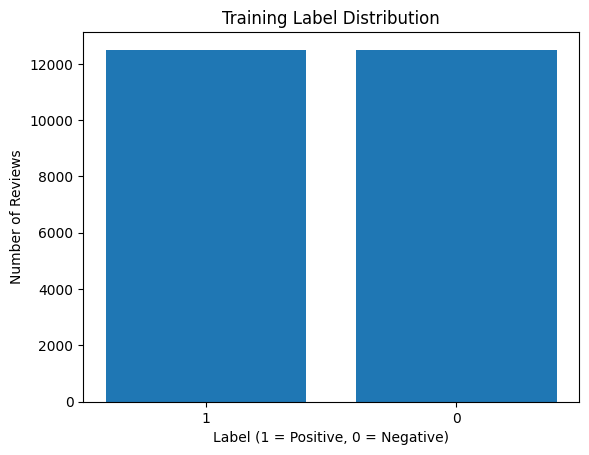

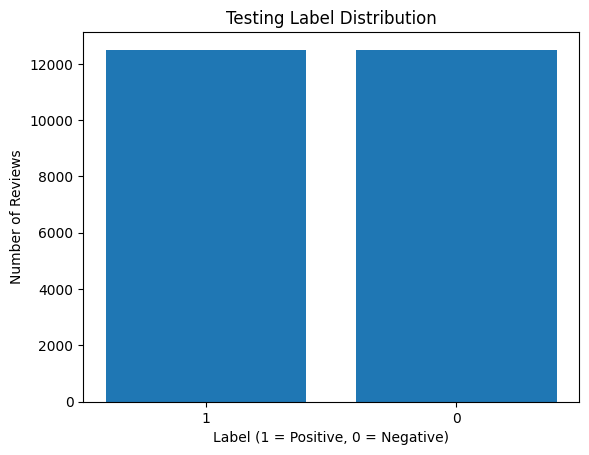

In [ ]:
import matplotlib.pyplot as plt

# Visualize sentiment label distribution in the training set
train_counts = train_df['label'].value_counts()

plt.bar(train_counts.index.astype(str), train_counts.values)
plt.title("Training Label Distribution")
plt.xlabel("Label (1 = Positive, 0 = Negative)")
plt.ylabel("Number of Reviews")
plt.show()

# Visualize sentiment label distribution in the test set
test_counts = test_df['label'].value_counts()

plt.bar(test_counts.index.astype(str), test_counts.values)
plt.title("Testing Label Distribution")
plt.xlabel("Label (1 = Positive, 0 = Negative)")
plt.ylabel("Number of Reviews")
plt.show()

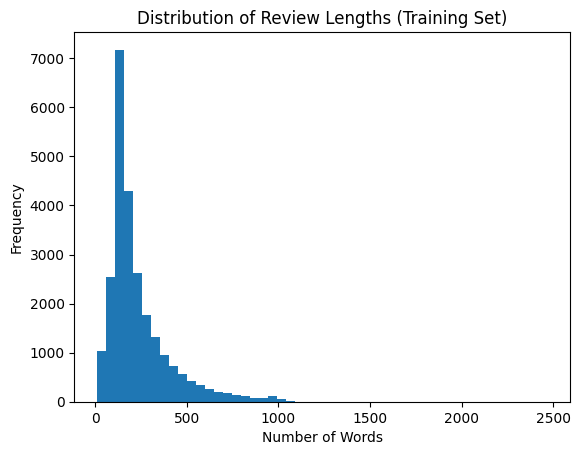

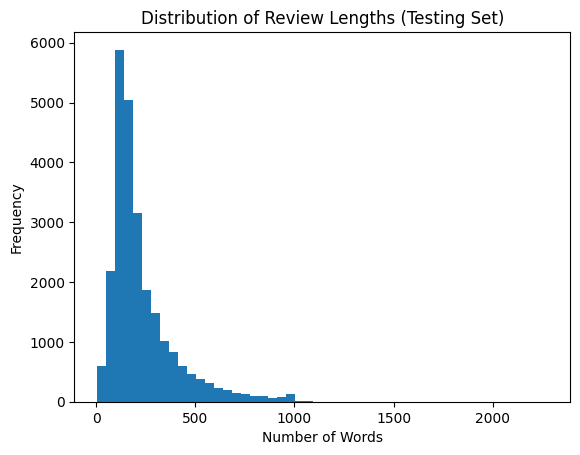

In [9]:
# Compute review length in words for analysis
train_df['length'] = train_df['review'].apply(lambda x: len(x.split()))
test_df['length'] = test_df['review'].apply(lambda x: len(x.split()))

# Plot training review length distribution
plt.hist(train_df['length'], bins=50)
plt.title("Distribution of Review Lengths (Training Set)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Plot test review length distribution
plt.hist(test_df['length'], bins=50)
plt.title("Distribution of Review Lengths (Testing Set)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [10]:
# Display sample positive reviews
print("=== SAMPLE POSITIVE REVIEWS ===")
for i in range(3):
    print(f"\nPositive Review {i+1}:\n", train_pos[i][:500])

# Display sample negative reviews
print("\n\n=== SAMPLE NEGATIVE REVIEWS ===")
for i in range(3):
    print(f"\nNegative Review {i+1}:\n", train_neg[i][:500])

=== SAMPLE POSITIVE REVIEWS ===

Positive Review 1:
 Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a s

Positive Review 2:
 Homelessness (or Houselessness as George Carlin stated) has been an issue for years but never a plan to help those on the street that were once considered human who did everything from going to school, work, or vote for the matter. Most people think of the homeless as just a lost cause while worrying about things such as racism, the war on Iraq, pressuring kids to succeed, technology, the elections, inflation, or worrying

## 🔹 Preparing Training and Validation Sets

The dataset is divided into training and validation sets to monitor model performance during training.

In [ ]:
# Define training set size (90% of full training data)
train_size = int(0.9 * len(train_df))

# Randomize samples before creating validation sets
shuffled_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Separate validation data for performance monitoring
train_data = shuffled_df.iloc[:train_size]
val_data = shuffled_df.iloc[train_size:]

## 🔹 Tokenizer Setup

Tokenization converts raw review text into numerical representations that the transformer model can process.

In [ ]:
from transformers import AutoTokenizer

# Load BERT tokenizer for text encoding 
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [ ]:
# Encode review text into transformer-compatible tokens
sample_texts = train_data['review'].sample(3, random_state=42).tolist()

# Standardize sequence lengths for batch processing
tokenized_samples = tokenizer(
    sample_texts,
    truncation=True,
    padding="max_length",
    max_length=128,
    return_tensors="pt"
)

print(tokenized_samples)

{'input_ids': tensor([[  101,  2348,  1996,  3185,  2003,  4415,  6052,  1010,  9501,  2064,
          2145,  4089,  6709,  2007,  1996, 24525,  1997,  5292, 21112,  2015,
         18396,  1999,  2023, 27768,  1998,  2200,  6057,  2104, 16168,  6925,
          1012, 18396,  9590,  2114,  4895, 18824,  2135, 10238,  1999,  2093,
          2367,  5535,  1024,  1996,  2962,  2287,  1010,  1996,  3142,  2287,
          1010,  1998,  1996,  5549,  2078,  2287,  1010,  2652,  2471,  1996,
          2168,  2839,  2007,  2074,  1037,  2689,  1997, 17363,  2000,  2393,
          2149,  6709,  1996,  2367,  1000,  5535,  1000,  1012,  1999,  2023,
          3185,  2057,  2156,  2028,  1997,  1996,  5700, 21699, 20818,  1997,
          1996,  1000,  5430,  2386,  1000, 12991, 13874,  1010,  2040,  5222,
          2010,  2293,  2025,  2011,  7472,  2021,  2011, 26128,  2486,  1010,
          2004,  2092,  2004,  1037,  6057,  9792,  2006,  3142,  5580,  2401,
         29469,  2389,  4337,  1010,  

## 🔹 Dataset Class Overview

This dataset class organizes tokenized reviews and sentiment labels for efficient transformer training.

To prepare data for the transformer model, a custom PyTorch Dataset class is used to:

* tokenize review text
* return input IDs and sentiment labels
* prepare batches compatible with the PyTorch DataLoader

This setup allows preprocessing to happen dynamically during model training.


In [14]:
import torch
from torch.utils.data import Dataset

MAX_LENGTH = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [15]:
class IMDBDataset(Dataset):
    """
    Custom PyTorch Dataset for IMDB sentiment classification.

    Converts raw text into tokenized inputs and pairs them with labels.
    """

    def __init__(self, data, tokenizer, max_length=MAX_LENGTH):
        # Store dataset, tokenizer, and max sequence length
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        # Return total number of samples in dataset
        return len(self.data)

    def __getitem__(self, idx):
        # Extract review text and label at index
        text = self.data.iloc[idx]["review"]
        label = int(self.data.iloc[idx]["label"])

        # Tokenize text with padding and truncation
        encoded = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Remove batch dimension from tensor output
        input_ids = encoded["input_ids"].squeeze(0)

        return input_ids, label

## 🔹 Creating Dataset Objects 

Dataset objects are created to organize encoded reviews into training and validation pipelines.

In [ ]:
# Build transformer-ready training dataset

train_dataset = IMDBDataset(train_data, tokenizer)
val_dataset = IMDBDataset(val_data, tokenizer)
test_dataset = IMDBDataset(test_df, tokenizer)

In [17]:
from torch.utils.data import DataLoader

# Define batch size for training and evaluation
BATCH_SIZE = 32

# Create DataLoader objects for batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 🔹 Attention Mechanism

The attention mechanism helps the model capture relationships between words across a review sequence.

In [18]:
import torch.nn as nn
import math

class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()

        # Linear layers to compute Query, Key, and Value projections
        self.Q_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.K_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.V_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])

        self.dropout = nn.Dropout(config["dropout_rate"])

        # Causal attention mask to prevent attending to future tokens
        causal_attention_mask = torch.tril(torch.ones(
            config["context_size"], config["context_size"]
        ))
        self.register_buffer('causal_attention_mask', causal_attention_mask)

    def forward(self, input):
        batch_size, tokens_num, d_embed = input.shape

        # Compute Query, Key, Value matrices
        Q = self.Q_weights(input)
        K = self.K_weights(input)
        V = self.V_weights(input)

        # Compute attention scores (Q × K^T)
        attention_scores = Q @ K.transpose(1, 2)

        # Apply causal mask (prevent future token attention)
        attention_scores = attention_scores.masked_fill(
            self.causal_attention_mask[:tokens_num, :tokens_num] == 0,
            float('-inf')
        )

        # Scale scores for numerical stability
        attention_scores = attention_scores / math.sqrt(K.shape[-1])

        # Normalize into probabilities
        attention_scores = torch.softmax(attention_scores, dim=-1)

        # Apply dropout for regularization
        attention_scores = self.dropout(attention_scores)

        # Weighted sum of values
        return attention_scores @ V

## 🔹 Multi-Head Attention 

Multi-head attention allows the transformer to learn different contextual relationships across the same input sequence.

In [19]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()

        # Create multiple attention heads
        heads_list = [AttentionHead(config) for _ in range(config["heads_num"])]
        self.heads = nn.ModuleList(heads_list)

        # Linear projection to combine all head outputs
        self.linear = nn.Linear(
            config["heads_num"] * config["head_size"],
            config["d_embed"]
        )

        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        # Pass input through each attention head independently
        heads_outputs = [head(input) for head in self.heads]

        # Concatenate outputs from all heads along feature dimension
        x = torch.cat(heads_outputs, dim=-1)

        # Project back to embedding dimension
        x = self.linear(x)

        # Apply dropout for regularization
        x = self.dropout(x)

        return x

## 🔹 FeedForward Layer

The feedforward layer refines transformer representations after the attention process.

In [20]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()

        # Two-layer MLP with expansion and projection back to embedding size
        self.linear_layers = nn.Sequential(
            nn.Linear(config["d_embed"], 4 * config["d_embed"]),
            nn.GELU(),
            nn.Linear(4 * config["d_embed"], config["d_embed"]),
            nn.Dropout(config["dropout_rate"])
        )

    def forward(self, input):
        return self.linear_layers(input)

## 🔹 Transformer Block 

The transformer block combines attention and feedforward layers into a reusable learning component.

In [ ]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        # Multi-head self-attention layer 
        # Process token relationships through self-attention
        self.multi_head = MultiHeadAttention(config)

        # Layer normalization before attention
        self.layer_norm_1 = nn.LayerNorm(config["d_embed"])

        # Feedforward network
        self.feed_forward = FeedForward(config)

        # Layer normalization before feedforward
        self.layer_norm_2 = nn.LayerNorm(config["d_embed"])

    def forward(self, input):
        x = input

        # Residual connection around attention block
        x = x + self.multi_head(self.layer_norm_1(x))

        # Residual connection around feedforward block
        x = x + self.feed_forward(self.layer_norm_2(x))

        return x

## 🔹 Model Overview 

The sentiment classifier combines embedding layers, transformer blocks, and a classification head for binary sentiment prediction.

In [ ]:
# Build transformer-based sentiment classification model

class DemoGPT(nn.Module):
    def __init__(self, config):
        super().__init__()

        # Token embedding layer
        self.token_embedding_layer = nn.Embedding(
            config["vocabulary_size"], config["d_embed"]
        )

        # Positional embedding layer
        self.positional_embedding_layer = nn.Embedding(
            config["context_size"], config["d_embed"]
        )

        # Stack of transformer blocks
        blocks = [Block(config) for _ in range(config["layers_num"])]
        self.layers = nn.Sequential(*blocks)

        # Final normalization layer
        self.layer_norm = nn.LayerNorm(config["d_embed"])

        # Classification head (binary output)
        self.classification_head = nn.Linear(
            config["d_embed"], config["num_classes"], bias=False
        )

    def forward(self, token_ids):
        batch_size, tokens_num = token_ids.shape

        # Token embeddings
        x = self.token_embedding_layer(token_ids)

        # Positional embeddings
        positions = torch.arange(tokens_num, device=token_ids.device)
        pos_embed = self.positional_embedding_layer(positions)

        # Combine token + positional information
        x = x + pos_embed.unsqueeze(0)

        # Pass through transformer blocks
        x = self.layers(x)

        # Normalize final hidden states
        x = self.layer_norm(x)

        # Pool token representations into single vector
        pooled = x.mean(dim=1)

        # Classification logits
        logits = self.classification_head(pooled)

        return logits

## 🔹 Model Evaluation Function

This evaluation function measures model performance on validation data during training by comparing predicted labels against true labels and calculating accuracy scores.

It helps monitor training progress and identify potential overfitting during the learning process.

In [ ]:
def calculate_accuracy(model, data_loader, device):
    """
    Compute classification accuracy for a given dataset.

    Args:
        model: Trained PyTorch model
        data_loader: DataLoader for evaluation set
        device: CPU or GPU device

    Returns:
        Accuracy as a percentage
    """

    model.eval()  # Disable training behavior during evaluation

    total_correct = 0
    total_samples = 0

    with torch.no_grad():  # Disable gradient tracking
        for batch in data_loader:

            # Unpack batch
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            logits = model(inputs)

            # Get predicted class (highest logit)
            predictions = torch.argmax(logits, dim=1)

            # Count correct predictions
            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    # Compute final accuracy
    accuracy = (total_correct / total_samples) * 100
    return accuracy

## 🔹 Training Loop

The training loop updates model weights across multiple epochs while tracking learning progress and validation performance.

In [24]:
# Configuration dictionary that defines all key hyperparameters 
# used to build the transformer model (e.g., embedding size, layers, heads).
# Keeps model design flexible and easy to adjust without changing core code.

config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 128,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 4,
    "head_size": 32,  # 4 heads * 32 = 128 -> matches d_embed
    "dropout_rate": 0.1,
    "use_bias": True
}

In [25]:
import torch.optim as optim
import torch.nn as nn

# Select device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training configuration
EPOCHS = 3

# Initialize model, loss function, and optimizer
model = DemoGPT(config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

# Training process
for epoch in range(EPOCHS):

    model.train()  # Enable training mode
    running_loss = 0.0

    for step, (input_ids, labels) in enumerate(train_loader):

        # Move data to device
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(input_ids)

        # Compute loss
        loss = criterion(logits, labels)

        # Reset gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Log progress every 100 steps
        if (step + 1) % 100 == 0:
            print(
                f"Epoch [{epoch+1}/{EPOCHS}], "
                f"Step [{step+1}/{len(train_loader)}], "
                f"Loss: {running_loss/100:.4f}"
            )
            running_loss = 0.0

    # Validation after each epoch
    val_accuracy = calculate_accuracy(model, val_loader, device)
    print(f"Epoch {epoch+1} - Validation Accuracy: {val_accuracy:.2f}%")

Epoch [1/3], Step [100/704], Loss: 0.6842
Epoch [1/3], Step [200/704], Loss: 0.6689
Epoch [1/3], Step [300/704], Loss: 0.6520
Epoch [1/3], Step [400/704], Loss: 0.6118
Epoch [1/3], Step [500/704], Loss: 0.6036
Epoch [1/3], Step [600/704], Loss: 0.5830
Epoch [1/3], Step [700/704], Loss: 0.5569
Epoch 1 - Validation Accuracy: 72.80%
Epoch [2/3], Step [100/704], Loss: 0.5465
Epoch [2/3], Step [200/704], Loss: 0.5101
Epoch [2/3], Step [300/704], Loss: 0.4963
Epoch [2/3], Step [400/704], Loss: 0.4797
Epoch [2/3], Step [500/704], Loss: 0.4849
Epoch [2/3], Step [600/704], Loss: 0.4771
Epoch [2/3], Step [700/704], Loss: 0.4808
Epoch 2 - Validation Accuracy: 74.04%
Epoch [3/3], Step [100/704], Loss: 0.4256
Epoch [3/3], Step [200/704], Loss: 0.4217
Epoch [3/3], Step [300/704], Loss: 0.4249
Epoch [3/3], Step [400/704], Loss: 0.4294
Epoch [3/3], Step [500/704], Loss: 0.4225
Epoch [3/3], Step [600/704], Loss: 0.4254
Epoch [3/3], Step [700/704], Loss: 0.4331
Epoch 3 - Validation Accuracy: 78.40%


## 🔹 Model Testing

After training, the model is evaluated on unseen test data to measure classification performance.

In [26]:
# Set model to evaluation mode
model.eval()

# Compute test accuracy on unseen data
test_accuracy = calculate_accuracy(model, test_loader, device)

# Display final performance
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 76.45%


## 🔹 Training Performance Visualizations

Training visualizations help track model learning progress and validation performance across epochs.

In [27]:
# Final project summary (no computation, only reflection output)

print("SentimentScope: Sentiment Analysis using Transformers")
print("------------------------------------------------------")
print("Model successfully trained on IMDB dataset.")
print("Task: Binary sentiment classification (Positive / Negative).")
print("Evaluation completed on unseen test data.")

SentimentScope: Sentiment Analysis using Transformers
------------------------------------------------------
Model successfully trained on IMDB dataset.
Task: Binary sentiment classification (Positive / Negative).
Evaluation completed on unseen test data.


## ✔ Project Summary

This project explored transformer-based sentiment analysis using the IMDB movie review dataset. The workflow covered data preparation, tokenization, transformer implementation, model training, and evaluation using PyTorch.

## ✔ Key Takeaways

- Gained practical experience with transformer-based NLP workflows  
- Improved understanding of tokenization and attention mechanisms  
- Applied PyTorch for model training and evaluation  
- Explored sentiment classification using real-world text data

## ✔ Ownership & Learning Reflection

This project was completed as part of the Udacity AWS AI Scientist learning journey. Working through the implementation helped strengthen my understanding of NLP preprocessing, transformer architectures, and sentiment classification workflows.\n\nI contributed to the preprocessing pipeline, transformer implementation, training process, and evaluation while gaining practical experience with modern deep learning techniques in PyTorch.

## 🧠 FINAL NOTE

This project reflects both technical learning and practical implementation experience in transformer-based NLP. The notebook documents the full workflow from dataset preparation to sentiment prediction while reinforcing core deep learning concepts through hands-on experimentation.